# 02. Credit Risk Prediction Model

前処理済みの訓練データ・テストデータを読み込み、ロジスティック回帰と XGBoost で与信リスク予測モデルを作成します。  
train データ内で 5-fold の交差検証を行い、平均 F1 スコアを基準に閾値を選定したうえで、モデル評価と特徴の寄与を確認します。


In [38]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    import shap
except ImportError:
    shap = None

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

sns.set_theme(style="whitegrid")


In [39]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"

data_path = DATA_DIR / "df_loan_transformed.parquet"
full_df = pd.read_parquet(data_path)

sampling_random_state = 42
accepted_full_df = full_df.loc[full_df["is_rejected"] == 0].copy()
rejected_full_df = full_df.loc[full_df["is_rejected"] == 1].copy()
rejected_full_df = rejected_full_df.sample(frac=0.15, random_state=sampling_random_state).reset_index(drop=True)
full_df = pd.concat([accepted_full_df, rejected_full_df], axis=0, ignore_index=True)

train_df, test_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=42,
    stratify=full_df["is_rejected"],
)

print("accepted full shape:", accepted_full_df.shape)
print("rejected full shape after sampling:", rejected_full_df.shape)
print("sampling random_state:", sampling_random_state)
print(f"full shape after sampling: {full_df.shape}")
print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
display(train_df.head())


accepted full shape: (144076, 56)
rejected full shape after sampling: (151831, 56)
sampling random_state: 42
full shape after sampling: (295907, 56)
train shape: (236725, 56)
test shape: (59182, 56)


,FICO_risk_score,dti_log1p,employment_length_ordinal,requested_loan_amount,state_AK,state_AL,state_AR,state_AZ,state_CA,state_CO,...,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,is_rejected
270432,622.0,3.335058,0.0,25000.0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
120559,732.0,2.544747,8.0,11125.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240443,672.0,3.608212,0.0,15000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
236588,727.0,4.387387,7.0,14500.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
175820,741.0,2.578701,9.0,14000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [40]:
target_col = "is_rejected"
n_splits = 5
random_state = 42

if target_col not in train_df.columns or target_col not in test_df.columns:
    raise ValueError(f"{target_col} must exist in both train_df and test_df for evaluation.")

state_cols = [col for col in train_df.columns if col.startswith("state_")]
feature_cols = [col for col in train_df.columns if col != target_col and col not in state_cols]

X_train_full = train_df[feature_cols].copy()
y_train_full_raw = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test_raw = test_df[target_col].copy()

non_numeric_cols = X_train_full.select_dtypes(exclude=["number", "bool"]).columns.tolist()
if non_numeric_cols:
    raise ValueError(f"Non-numeric columns remain after preprocessing: {non_numeric_cols}")

label_encoder = LabelEncoder()
label_encoder.fit(y_train_full_raw)

y_train_full = label_encoder.transform(y_train_full_raw)
y_test = label_encoder.transform(y_test_raw)

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_names = [str(label) for label in label_encoder.classes_]
positive_class_label = label_encoder.classes_[1]

print(f"target column: {target_col}")
print(f"number of features: {len(feature_cols)}")
print(f"positive class label: {positive_class_label}")
print(f"cv folds: {n_splits}")
print("class mapping:", class_mapping)
print("train_full target distribution:")
display(y_train_full_raw.value_counts(normalize=True).rename("ratio"))
print("test target distribution:")
display(y_test_raw.value_counts(normalize=True).rename("ratio"))


target column: is_rejected
number of features: 4
positive class label: 1
cv folds: 5
class mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
train_full target distribution:


is_rejected
1    0.513102
0    0.486898
Name: ratio, dtype: float64

test target distribution:


is_rejected
1    0.513112
0    0.486888
Name: ratio, dtype: float64

In [41]:
# Fit the final scaler on the full training data for the final model and coefficient inspection.
scaler = StandardScaler()

X_train_full_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=feature_cols,
    index=X_train_full.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

display(X_train_full_scaled.head())


,FICO_risk_score,dti_log1p,employment_length_ordinal,requested_loan_amount
270432,-0.200799,0.686813,-0.847107,1.234893
120559,0.613258,-0.117864,1.217909,-0.235403
240443,0.169227,0.964933,-0.847107,0.175220
236588,0.576255,1.758272,0.959782,0.122236
175820,0.679862,-0.083293,1.476036,0.069253


## Logistic Regression Training

train データ内で 5-fold の交差検証を行い、各 threshold における平均 F1 スコアを比較して最適閾値を選びます。  
標準化は各 fold の学習データで fit し、fold の検証データには transform のみを適用します。


In [42]:
threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
cv_metric_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train_full, y_train_full), start=1):
    X_train_fold = X_train_full.iloc[train_idx]
    X_valid_fold = X_train_full.iloc[valid_idx]
    y_train_fold = y_train_full[train_idx]
    y_valid_fold = y_train_full[valid_idx]

    fold_scaler = StandardScaler()
    X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
    X_valid_fold_scaled = fold_scaler.transform(X_valid_fold)

    fold_model = LogisticRegression(
        max_iter=2000,
        random_state=random_state,
    )
    fold_model.fit(X_train_fold_scaled, y_train_fold)

    fold_valid_pred_proba = fold_model.predict_proba(X_valid_fold_scaled)[:, 1]

    for threshold in threshold_grid:
        fold_valid_pred = (fold_valid_pred_proba >= threshold).astype(int)
        cv_metric_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "accuracy": accuracy_score(y_valid_fold, fold_valid_pred),
                "precision": precision_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "recall": recall_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "f1": f1_score(y_valid_fold, fold_valid_pred, zero_division=0),
            }
        )

cv_metrics_df = pd.DataFrame(cv_metric_rows)
logistic_threshold_candidates = (
    cv_metrics_df.groupby("threshold", as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .sort_values(["f1", "threshold"], ascending=[False, True])
    .reset_index(drop=True)
)

logistic_best_threshold = (
    logistic_threshold_candidates.iloc[0]["threshold"]
    if not logistic_threshold_candidates.empty else 0.5
)

print("cross-validation completed")
print(f"selected threshold from 5-fold mean f1: {logistic_best_threshold:.4f}")


cross-validation completed
selected threshold from 5-fold mean f1: 0.5500


In [43]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=random_state,
)
logistic_model.fit(X_train_full_scaled, y_train_full)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [44]:
logistic_test_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
logistic_test_pred = (logistic_test_pred_proba >= logistic_best_threshold).astype(int)

In [45]:
logistic_metrics = {
    "accuracy": accuracy_score(y_test, logistic_test_pred),
    "precision": precision_score(y_test, logistic_test_pred, zero_division=0),
    "recall": recall_score(y_test, logistic_test_pred, zero_division=0),
    "f1": f1_score(y_test, logistic_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, logistic_test_pred_proba),
}

logistic_metrics_df = pd.DataFrame(logistic_metrics, index=["test"]).T.rename(columns={"test": "value"})
display(logistic_metrics_df)



,value
accuracy,0.848434
precision,0.872031
recall,0.825798
f1,0.848285
roc_auc,0.914985


,0,1
0,25135,3680
1,5290,25077


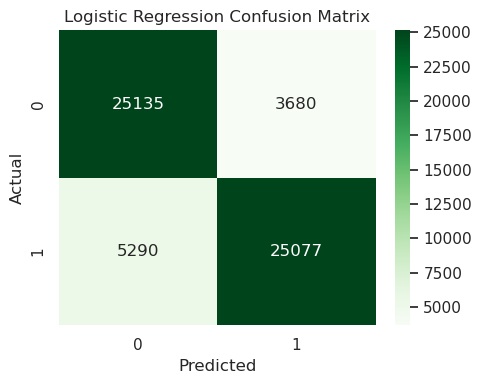

In [46]:
logistic_cm = confusion_matrix(y_test, logistic_test_pred)
logistic_cm_df = pd.DataFrame(logistic_cm, index=class_names, columns=class_names)
display(logistic_cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(logistic_cm_df, annot=True, fmt="d", cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [47]:
logistic_prediction_result = X_test.copy()
logistic_prediction_result["actual"] = y_test_raw.values
logistic_prediction_result["prediction"] = label_encoder.inverse_transform(logistic_test_pred)
logistic_prediction_result["prediction_proba"] = logistic_test_pred_proba

display(logistic_prediction_result.head())
display(logistic_threshold_candidates.head(10))


,FICO_risk_score,dti_log1p,employment_length_ordinal,requested_loan_amount,actual,prediction,prediction_proba
9940,737.0,2.841415,0.0,11500.0,0,0,0.367540
242191,628.0,3.113960,0.0,17000.0,1,1,0.936339
266858,656.0,1.532557,0.0,20000.0,1,1,0.852327
69909,662.0,3.539509,9.0,2400.0,0,0,0.107756
92973,782.0,2.574138,10.0,15000.0,0,0,0.004758


,threshold,accuracy,precision,recall,f1,f1_std
0,0.55,0.848039,0.870313,0.827085,0.848147,0.001697
1,0.57,0.849564,0.880152,0.818226,0.848059,0.001806
2,0.54,0.847118,0.865299,0.831481,0.848052,0.001996
3,0.56,0.848689,0.875008,0.822614,0.848001,0.001608
4,0.58,0.850105,0.885098,0.813467,0.847771,0.001938
5,0.53,0.845999,0.860186,0.835696,0.847763,0.001875
6,0.59,0.850620,0.890076,0.808750,0.847465,0.001927
7,0.52,0.844782,0.854947,0.840010,0.847412,0.001753
8,0.60,0.851313,0.895491,0.804057,0.847314,0.001742
9,0.61,0.851710,0.900772,0.799010,0.846845,0.001790


## Logistic Coefficients

標準化後特徴量に対するロジスティック回帰の係数を確認します。


,feature,coefficient,abs_coefficient
0,FICO_risk_score,-3.634824,3.634824
1,employment_length_ordinal,-1.430401,1.430401
2,requested_loan_amount,0.419904,0.419904
3,dti_log1p,0.196097,0.196097


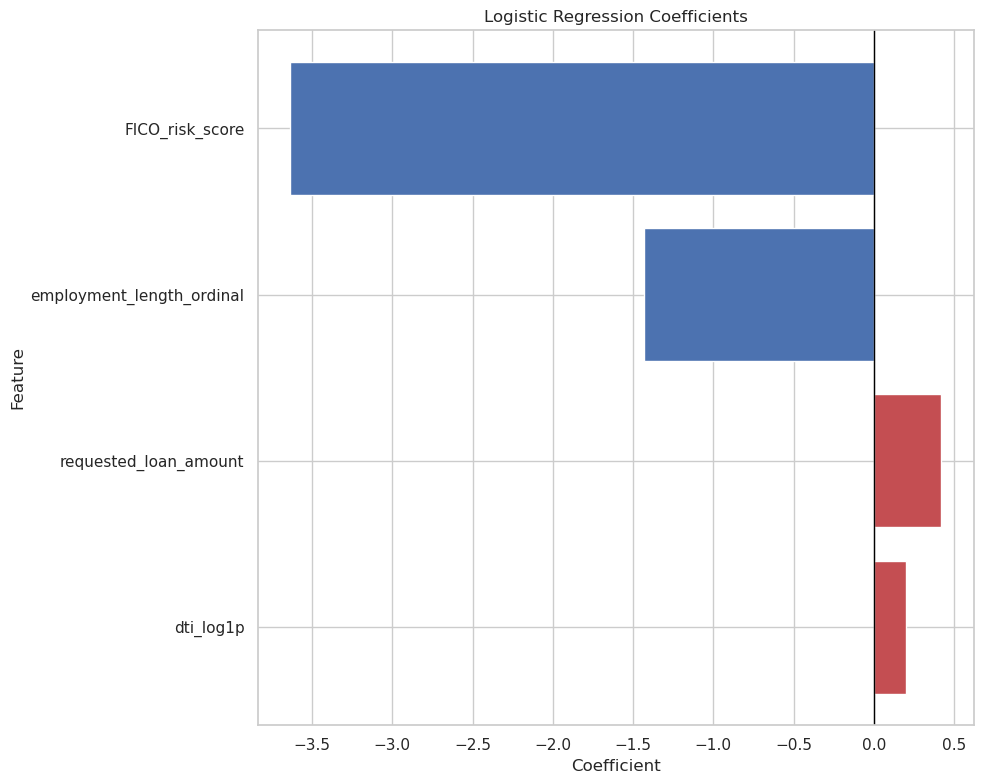

In [48]:
logistic_coef_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "coefficient": logistic_model.coef_.ravel(),
        }
    )
    .assign(abs_coefficient=lambda df_: df_["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

display(logistic_coef_df.head(20))

plot_coef_df = logistic_coef_df.head(20)
plot_colors = ["#c44e52" if coef > 0 else "#4c72b0" for coef in plot_coef_df["coefficient"]]

plt.figure(figsize=(10, 8))
plt.barh(plot_coef_df["feature"], plot_coef_df["coefficient"], color=plot_colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## XGBoost Training


In [49]:
if XGBClassifier is None:
    raise ImportError("xgboost is not installed. Install xgboost in this kernel before running the XGBoost section.")

xgb_threshold_grid = threshold_grid.copy()
xgb_cv_metric_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train_full, y_train_full), start=1):
    X_train_fold = X_train_full.iloc[train_idx]
    X_valid_fold = X_train_full.iloc[valid_idx]
    y_train_fold = y_train_full[train_idx]
    y_valid_fold = y_train_full[valid_idx]

    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=random_state,
        n_jobs=-1,
    )
    fold_model.fit(X_train_fold, y_train_fold)

    fold_valid_pred_proba = fold_model.predict_proba(X_valid_fold)[:, 1]

    for threshold in xgb_threshold_grid:
        fold_valid_pred = (fold_valid_pred_proba >= threshold).astype(int)
        xgb_cv_metric_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "accuracy": accuracy_score(y_valid_fold, fold_valid_pred),
                "precision": precision_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "recall": recall_score(y_valid_fold, fold_valid_pred, zero_division=0),
                "f1": f1_score(y_valid_fold, fold_valid_pred, zero_division=0),
            }
        )

xgb_cv_metrics_df = pd.DataFrame(xgb_cv_metric_rows)
xgb_threshold_candidates = (
    xgb_cv_metrics_df.groupby("threshold", as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .sort_values(["f1", "threshold"], ascending=[False, True])
    .reset_index(drop=True)
)

xgb_best_threshold = xgb_threshold_candidates.iloc[0]["threshold"] if not xgb_threshold_candidates.empty else 0.5

print("cross-validation completed")
print(f"selected XGBoost threshold from 5-fold mean f1: {xgb_best_threshold:.4f}")


cross-validation completed
selected XGBoost threshold from 5-fold mean f1: 0.4200


In [50]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=random_state,
    n_jobs=-1,
)
xgb_model.fit(X_train_full, y_train_full)

xgb_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_pred_proba >= xgb_best_threshold).astype(int)


,value
accuracy,0.955949
precision,0.971596
recall,0.941680
f1,0.956404
roc_auc,0.986800


,0,1
0,27979,836
1,1771,28596


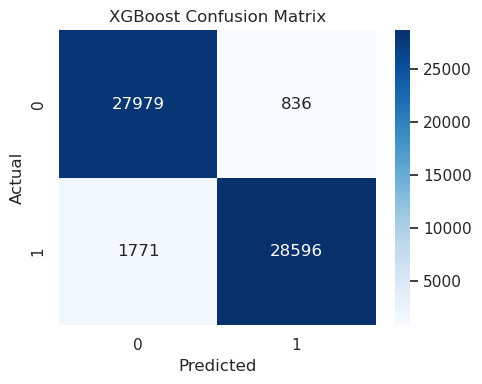

In [51]:
xgb_metrics = {
    "accuracy": accuracy_score(y_test, xgb_test_pred),
    "precision": precision_score(y_test, xgb_test_pred, zero_division=0),
    "recall": recall_score(y_test, xgb_test_pred, zero_division=0),
    "f1": f1_score(y_test, xgb_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, xgb_test_pred_proba),
}

xgb_metrics_df = pd.DataFrame(xgb_metrics, index=["test"]).T.rename(columns={"test": "value"})
display(xgb_metrics_df)

xgb_cm = confusion_matrix(y_test, xgb_test_pred)
xgb_cm_df = pd.DataFrame(xgb_cm, index=class_names, columns=class_names)
display(xgb_cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(xgb_cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [52]:
xgb_prediction_result = X_test.copy()
xgb_prediction_result["actual"] = y_test_raw.values
xgb_prediction_result["prediction"] = label_encoder.inverse_transform(xgb_test_pred)
xgb_prediction_result["prediction_proba"] = xgb_test_pred_proba

display(xgb_prediction_result.head())
display(xgb_threshold_candidates.head(10))


,FICO_risk_score,dti_log1p,employment_length_ordinal,requested_loan_amount,actual,prediction,prediction_proba
9940,737.0,2.841415,0.0,11500.0,0,0,0.225732
242191,628.0,3.113960,0.0,17000.0,1,1,0.999156
266858,656.0,1.532557,0.0,20000.0,1,1,0.995119
69909,662.0,3.539509,9.0,2400.0,0,0,0.067599
92973,782.0,2.574138,10.0,15000.0,0,0,0.081740


,threshold,accuracy,precision,recall,f1,f1_std
0,0.42,0.958479,0.972114,0.946223,0.958993,0.000385
1,0.43,0.958429,0.973016,0.945194,0.958902,0.000249
2,0.44,0.958382,0.973970,0.944123,0.958814,0.000349
3,0.41,0.958238,0.970588,0.947318,0.958811,0.000307
4,0.40,0.958141,0.969339,0.948421,0.958765,0.000258
5,0.39,0.958027,0.968064,0.949524,0.958704,0.000328
6,0.45,0.958314,0.975266,0.942666,0.958688,0.000389
7,0.46,0.958331,0.976459,0.941489,0.958655,0.000410
8,0.38,0.957723,0.966603,0.950446,0.958455,0.000319
9,0.47,0.958108,0.977673,0.939818,0.958371,0.000447


## XGBoost SHAP


,feature,mean_abs_shap
0,FICO_risk_score,2.920324
1,employment_length_ordinal,1.085326
2,dti_log1p,1.081712
3,requested_loan_amount,0.397475


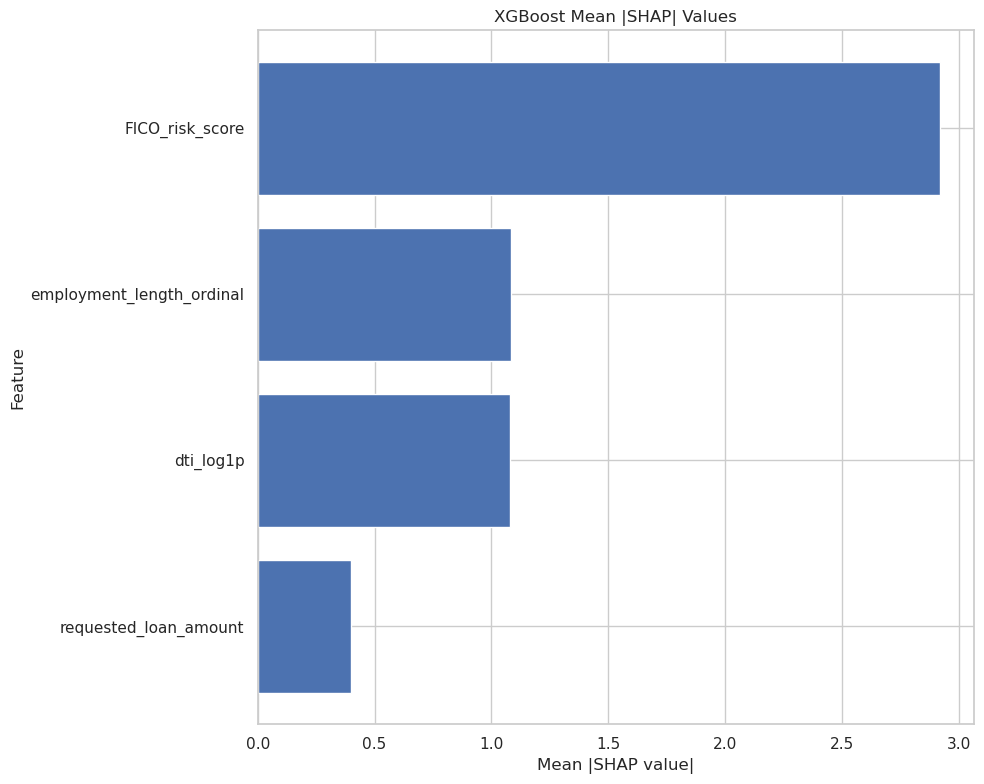

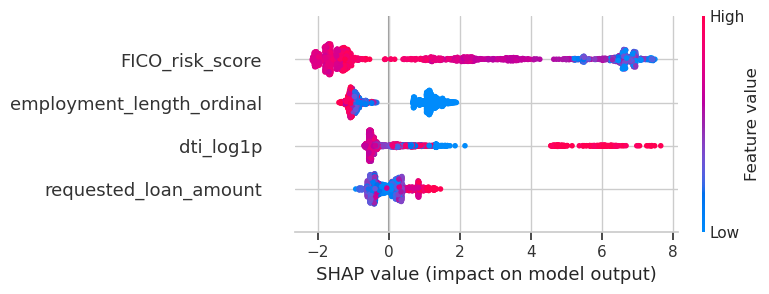

In [53]:
xgb_shap_sample_size = min(2000, len(X_test))
xgb_shap_input = X_test.sample(n=xgb_shap_sample_size, random_state=random_state).copy()

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(xgb_shap_input)

xgb_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "mean_abs_shap": np.abs(xgb_shap_values).mean(axis=0),
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(xgb_importance_df.head(20))

plot_importance_df = xgb_importance_df.head(20).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_importance_df["feature"], plot_importance_df["mean_abs_shap"], color="#4c72b0")
plt.title("XGBoost Mean |SHAP| Values")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

shap.summary_plot(xgb_shap_values, xgb_shap_input, plot_type="dot", max_display=20)


## Model Save


In [54]:
MODEL_DIR = BASE_DIR / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

logistic_artifact = {
    "model": logistic_model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "target_col": target_col,
    "class_names": class_names,
    "class_mapping": class_mapping,
    "best_threshold": logistic_best_threshold,
}

logistic_artifact_path = MODEL_DIR / "loan_logistic_artifact.joblib"
joblib.dump(logistic_artifact, logistic_artifact_path)

xgb_artifact = {
    "model": xgb_model,
    "scaler": None,
    "feature_cols": feature_cols,
    "target_col": target_col,
    "class_names": class_names,
    "class_mapping": class_mapping,
    "best_threshold": xgb_best_threshold,
}

xgb_artifact_path = MODEL_DIR / "loan_xgb_artifact.joblib"
joblib.dump(xgb_artifact, xgb_artifact_path)

print(f"saved logistic artifact to: {logistic_artifact_path}")
print(f"saved xgboost artifact to: {xgb_artifact_path}")


saved logistic artifact to: /home/kohei/WorkSpace/blog/01.Counterfactual_Analysis/model/loan_logistic_artifact.joblib
saved xgboost artifact to: /home/kohei/WorkSpace/blog/01.Counterfactual_Analysis/model/loan_xgb_artifact.joblib


In [55]:
loan_test_df = test_df.copy()

train_output_path = DATA_DIR / "train_df.parquet"
loan_test_output_path = DATA_DIR / "test_df.parquet"

train_df.to_parquet(train_output_path, index=False)
loan_test_df.to_parquet(loan_test_output_path, index=False)

print(f"saved train_df to: {train_output_path}")
print(f"saved test_df to: {loan_test_output_path}")


saved train_df to: /home/kohei/WorkSpace/blog/01.Counterfactual_Analysis/data/train_df.parquet
saved test_df to: /home/kohei/WorkSpace/blog/01.Counterfactual_Analysis/data/test_df.parquet
